# cGAN Training

### Goal - To build and train our **conditional GAN (cGAN)** - a generative model that learsn to create **synthetic handwriting images** conditioned on digit labels

## Plan 

1. Understand the architecture of a **conditional Gan (cGAN)**
2. Implement **Generator** and **discriminator** in pytorch
3. Train model with adversarial objectives
4. Visualise class-conditional handwriting samples

## Recap (cGAN)

A **Generative Adversarial Network (GAN)** consists of:
- A **Generator (G)** that creates fake samples from random noise.
- A **Discriminator (D)** that tries to tell real from fake.

In a **Conditional GAN**, both G and D receive an **additional input**: a *class label*.  
This allows the model to generate specific digits or characters on demand.

In [1]:
# import core libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np

import os, sys

from data_utils.dataloader import get_mnist_loaders
from model.cgan import Generator, Discriminator
from utils.visualize import show_batch
from utils.checkpoint import save_checkpoint

device = (
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)
print(f" Running on device: {device}")

 Running on device: cuda


### Define Model Hyperparameters 


We’ll use a low-dimensional latent space (`z_dim = 100`),  
and condition the model on **10 digit classes (0–9)**.

GANs are notoriously sensitive to hyperparameters —  
we’ll start simple and iterate.

In [2]:
# hyperparameters 
z_dim = 100
num_classes = 10
img_shape = (1, 28, 28)
batch_size = 128
lr = 0.0002
epochs = 50

In [3]:
#ToDO: extract the data 
#Tip: Use the `get_mnist_loader` function in dataloader.py
train_loader, test_loader = get_mnist_loaders(batch_size=batch_size)

In [4]:
img, _ = next(iter(train_loader))
print(img.shape)
img, _ = next(iter(test_loader))
print(img.shape)
print(len(train_loader), len(test_loader))

torch.Size([128, 1, 28, 28])
torch.Size([128, 1, 28, 28])
469 79


Before we dive into training, let's define both our **Generator** and **Discriminator**.

Each will use the label embedding trick — where we turn the class label (e.g., “3”) into a learnable vector that can be concatenated with the noise or image input.

Our models are intentionally **lightweight** to make training on CPU/MPS feasible.  We’ll focus on the learning process and class conditioning rather than pixel-perfect realism.

In [5]:
##ToDo: initialize models and optimizers
model_d = Discriminator().to(device)
model_g = Generator().to(device)
optim_d = torch.optim.Adam(model_d.parameters(), lr= 0.0002, betas=(0.5, 0.999))
optim_g = torch.optim.Adam(model_g.parameters(), lr= 0.0002, betas=(0.5, 0.999))

In [6]:
criterion = nn.BCELoss()

## Training Strategy

We’ll alternate between training the **Discriminator (D)** and **Generator (G)**.

1. **Train D:**  
   - Use real images labeled as 1  
   - Use fake images (from G) labeled as 0  

2. **Train G:**  
   - Generate fake images  
   - Fool D into predicting them as 1  

This adversarial game continues until G generates *realistic*, class-conditioned digits.

In [7]:
device

'cuda'

In [8]:
#ToDo:    
     # 1.  Implement training loop 
     # 2. Save D & G every 10 epochs
from training.train_cgan import train_cgan

In [9]:
train_cgan(
    generator=model_g,
    discriminator=model_d,
    dataloader=train_loader,
    optimizer_G=optim_g,
    optimizer_D=optim_d,
    criterion=criterion,
    device=device,
    z_dim=z_dim,
    num_classes=num_classes,
    epochs=epochs,
)

[Epoch 1/50] D loss: 0.4533 | G loss: 0.6484
[Epoch 2/50] D loss: 0.2915 | G loss: 1.7444
[Epoch 3/50] D loss: 0.3707 | G loss: 1.1623
[Epoch 4/50] D loss: 0.3277 | G loss: 1.4892
[Epoch 5/50] D loss: 0.3045 | G loss: 1.2086
[Epoch 6/50] D loss: 0.3348 | G loss: 1.0115
[Epoch 7/50] D loss: 0.3363 | G loss: 1.0698
[Epoch 8/50] D loss: 0.3806 | G loss: 2.9065
[Epoch 9/50] D loss: 0.4205 | G loss: 0.8427
[Epoch 10/50] D loss: 0.3278 | G loss: 1.0026
Saved checkpoints at epoch 10
[Epoch 11/50] D loss: 0.3081 | G loss: 1.4048
[Epoch 12/50] D loss: 0.2637 | G loss: 1.2922
[Epoch 13/50] D loss: 1.1287 | G loss: 6.1281
[Epoch 14/50] D loss: 0.3085 | G loss: 2.3207
[Epoch 15/50] D loss: 0.4777 | G loss: 0.6282
[Epoch 16/50] D loss: 0.3064 | G loss: 3.6448
[Epoch 17/50] D loss: 0.3023 | G loss: 1.2766
[Epoch 18/50] D loss: 0.3186 | G loss: 1.6913
[Epoch 19/50] D loss: 0.3210 | G loss: 1.0359
[Epoch 20/50] D loss: 0.3369 | G loss: 2.8154
Saved checkpoints at epoch 20
[Epoch 21/50] D loss: 0.1951 

In [10]:

# ToDo: Save Final Model
save_checkpoint(model=model_d, optimizer=optim_d, epoch=epochs, loss=None, name="model_d", path="../checkpoints")
save_checkpoint(model=model_g, optimizer=optim_g, epoch=epochs, loss=None, name="model_g", path="../checkpoints")

Saved checkpoint: ../checkpoints/model_d_epoch50.pt
Saved checkpoint: ../checkpoints/model_g_epoch50.pt


### Note
Training GANs can be unstable.  
If losses oscillate, that’s expected — D and G are in constant competition.

Let’s visualize a few generated samples at the end of training to check if conditioning worked.

In [12]:
from utils.checkpoint import load_checkpoint
generator = load_checkpoint(model_g, optimizer=optim_g, path='../checkpoints/model_g_epoch50.pt', map_location="cuda")

Loaded model weights from ../checkpoints/model_g_epoch50.pt


/workspace/code/project/starter/utils/checkpoint.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=map_location)


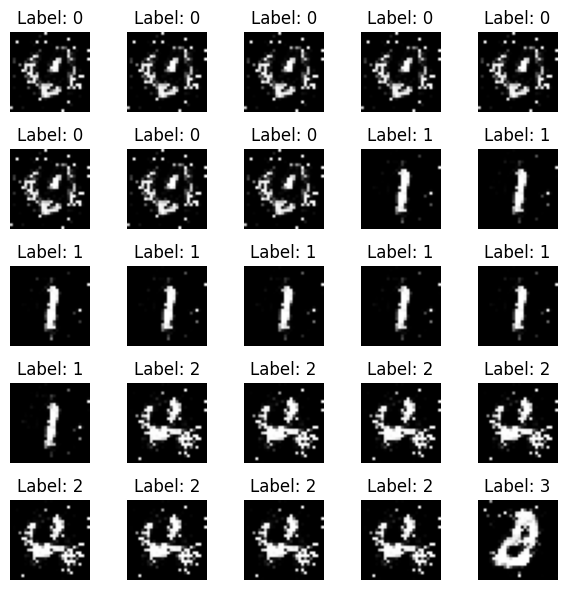

In [13]:
### Generate and visualize samples
def generate_samples(generator, n_classes=10, n_per_class=8):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_classes * n_per_class, z_dim).to(device)
        labels = torch.tensor([i for i in range(n_classes) for _ in range(n_per_class)]).to(device)
        gen_imgs = generator(z, labels)
    generator.train()
    return gen_imgs, labels

gen_imgs, gen_labels = generate_samples(generator)
show_batch(gen_imgs.cpu(), gen_labels.cpu(), n=25)

We can now see grids of digits 0–9, each set showing several synthetic examples.  
Each class label corresponds to the digit the Generator was conditioned on.

Even if the images look a bit fuzzy, the model has learned the *concept* of conditioning —  
the generator “knows” which class to produce.